<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EP3_Transformer_Traduccion_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°3 — Entregable 2: Modelo Transformer
## Deep Learning (DLY0100) — Traducción Automática Inglés → Español

**Integrante:** Nicolas Silva
**Fecha:** 03 Julio 2026

---

## 1. Introducción

### Descripción del problema

Se implementa una arquitectura **Transformer** (encoder-decoder con *multi-head attention*) construida desde
cero (sin usar `keras.Sequential` de alto nivel ni modelos preentrenados), aplicada a la tarea de **traducción
automática de oraciones cortas del inglés al español**.

Se usa el dataset `spa-eng` (~119.000 pares de oraciones inglés-español), alojado directamente por TensorFlow,
por lo que se descarga automáticamente al ejecutar la celda de carga de datos (no requiere configuración
adicional en Colab).

### ¿Por qué traducción automática y no clasificación?

A diferencia del Entregable 1 (RNN/LSTM, que resuelve una **clasificación** — sentimiento positivo/negativo), la
traducción es una tarea **secuencia-a-secuencia (seq2seq)**: la entrada y la salida son ambas secuencias de
largo variable y en idiomas distintos. Este tipo de tarea es el caso de uso "de manual" del Transformer, porque
requiere exactamente los dos mecanismos que la arquitectura resuelve mejor que una RNN: (1) relacionar cada
palabra de salida con las palabras relevantes de la entrada (*cross-attention*) y (2) generar la salida palabra
por palabra sin perder el contexto de lo ya generado (*self-attention* enmascarada).

### Objetivos

1. Implementar una arquitectura Transformer básica (encoder, decoder, multi-head attention).
2. Explicar el rol de cada componente (embeddings + codificación posicional, autoatención, feed-forward).
3. Aplicar el modelo a la tarea de traducción automática.
4. Evaluar el desempeño con la métrica **BLEU**.
5. Analizar críticamente ejemplos de traducciones (aciertos y errores).


In [1]:
# Librerías principales
# - numpy / pandas: manejo de arreglos y tablas de resultados
# - matplotlib: gráficos de entrenamiento y de métricas
# - re / string: limpieza de texto (expresiones regulares y puntuación)
# - random: muestreo reproducible de ejemplos
# - tensorflow / keras: construcción y entrenamiento del modelo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# Fijamos una semilla en todas las fuentes de aleatoriedad para que el notebook
# sea reproducible: mismo split de datos, misma inicialización de pesos, etc.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


TensorFlow version: 2.20.0


In [2]:
# NLTK para calcular BLEU
# BLEU (Bilingual Evaluation Understudy) compara n-gramas de la traducción generada
# contra una traducción de referencia humana. Es la métrica estándar en traducción
# automática, pedida explícitamente en la pauta de evaluación.
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# La "smoothing function" evita que el BLEU se vaya a 0 exacto cuando falta algún
# n-grama completo (algo muy común en oraciones cortas), lo que daría una métrica
# poco informativa. method4 es la recomendada por la literatura para frases cortas.
smoothie = SmoothingFunction().method4


## 2. Carga y preprocesamiento de datos

El dataset contiene pares `(oración en inglés, oración en español)` separados por tabulador. Se limpia el texto
(minúsculas, se quita puntuación no relevante) y se agregan los tokens especiales `[start]` y `[end]` a las
oraciones en español, que el decoder necesita para saber cuándo comenzar y terminar de generar la traducción.

**¿Por qué solo el español lleva `[start]`/`[end]` y el inglés no?** Porque el inglés es la secuencia de
*entrada* al encoder (se procesa completa de una sola vez), mientras que el español es la secuencia que el
decoder debe *generar* token por token — necesita una señal explícita de "parte aquí" y "termina aquí".


In [3]:
import os

# get_file descarga el .zip una sola vez y lo cachea en el entorno de Colab;
# en ejecuciones posteriores reutiliza el archivo ya descargado.
text_file_dir = keras.utils.get_file(
    fname="spa-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip",
    extract=True,
)
# El archivo 'spa.txt' queda dentro de una subcarpeta 'spa-eng' una vez extraído.
text_file = os.path.join(text_file_dir, "spa-eng", "spa.txt")

with open(text_file, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]  # la última línea del archivo viene vacía

text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    spa = "[start] " + spa + " [end]"
    text_pairs.append((eng, spa))

print(f"Total de pares: {len(text_pairs)}")
for pair in random.sample(text_pairs, 3):
    print(pair)


2638744/2638744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total de pares: 118964
('There is no doubt about his ability.', '[start] No hay ninguna duda sobre su habilidad. [end]')
('They were amazing.', '[start] Fueron maravillosos. [end]')
("That'll last.", '[start] Durará. [end]')


In [4]:
# Split train / val / test (70% / 15% / 15% aprox.)
# Se mezclan los pares antes de dividir para que los tres conjuntos tengan una
# mezcla representativa de oraciones cortas/largas y de distintos temas.
random.shuffle(text_pairs)
n_val = int(0.15 * len(text_pairs))
n_train = len(text_pairs) - 2 * n_val

train_pairs = text_pairs[:n_train]
val_pairs = text_pairs[n_train:n_train + n_val]
test_pairs = text_pairs[n_train + n_val:]

print(f"{len(train_pairs)} pares de entrenamiento")
print(f"{len(val_pairs)} pares de validación")
print(f"{len(test_pairs)} pares de prueba")


83276 pares de entrenamiento
17844 pares de validación
17844 pares de prueba


In [5]:
# TextVectorization convierte texto crudo en secuencias de enteros (tokenización +
# construcción de vocabulario), de forma análoga a lo que hicimos "a mano" con
# keras.datasets.imdb en el Entregable 1, pero aquí se ajusta (adapt) sobre
# nuestro propio corpus en vez de venir precalculado.

# Quitamos toda la puntuación EXCEPTO los corchetes [ ], porque los necesitamos
# para conservar los tokens especiales [start] y [end] como palabras completas.
strip_chars = string.punctuation.replace("[", "").replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, f"[{re.escape(strip_chars)}]", "")

VOCAB_SIZE = 15000   # palabras más frecuentes que se conservan (el resto -> [UNK])
SEQ_LENGTH = 20       # largo fijo de las secuencias (en tokens), por padding/truncado

# Vectorizador de inglés (entrada del encoder): usa la estandarización por defecto
# de Keras (minúsculas + quitar puntuación estándar), no necesita preservar [start]/[end].
eng_vectorization = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int", output_sequence_length=SEQ_LENGTH
)
# Vectorizador de español (entrada/salida del decoder): usa nuestra estandarización
# personalizada para no destruir los tokens [start]/[end]. Se usa SEQ_LENGTH + 1
# porque luego, al entrenar, se desplaza la secuencia en un token (ver más abajo).
spa_vectorization = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int", output_sequence_length=SEQ_LENGTH + 1,
    standardize=custom_standardization,
)

# adapt() recorre el corpus de ENTRENAMIENTO (nunca validación/test, para evitar
# fuga de información) y construye el vocabulario ordenado por frecuencia.
train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]
eng_vectorization.adapt(train_eng_texts)
spa_vectorization.adapt(train_spa_texts)

print("Vocabulario inglés:", len(eng_vectorization.get_vocabulary()))
print("Vocabulario español:", len(spa_vectorization.get_vocabulary()))


Vocabulario inglés: 12062
Vocabulario español: 15000


In [6]:
def format_dataset(eng, spa):
    """Convierte un par de texto crudo en el formato de entrada/salida del modelo.

    Concepto clave: "teacher forcing". Durante el entrenamiento, el decoder no
    recibe sus propias predicciones anteriores (eso lo haremos recién en la
    inferencia con decode_sequence), sino la secuencia de referencia REAL,
    desplazada en un token:
      - decoder_inputs = spa[0 .. n-1]  (todo menos el último token)
      - target         = spa[1 .. n]    (todo menos el primero, es decir "un paso adelante")
    Así, en cada posición i, el modelo aprende a predecir el token i+1 de la
    referencia, dado el contexto real hasta el token i. Esto acelera mucho el
    entrenamiento respecto a alimentar las propias predicciones del modelo.
    """
    eng = eng_vectorization(eng)
    spa = spa_vectorization(spa)
    return ({"encoder_inputs": eng, "decoder_inputs": spa[:, :-1]}, spa[:, 1:])

def make_dataset(pairs, batch_size=64):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts, spa_texts = list(eng_texts), list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    # shuffle: evita que el modelo aprenda algún orden espurio de los datos.
    # prefetch: solapa la preparación del siguiente batch con el cómputo del actual (más rápido).
    # cache: guarda el dataset ya vectorizado en memoria tras la primera época (evita repetir el preprocesamiento).
    return dataset.shuffle(2048).prefetch(tf.data.AUTOTUNE).cache()

BATCH_SIZE = 64
train_ds = make_dataset(train_pairs, BATCH_SIZE)
val_ds = make_dataset(val_pairs, BATCH_SIZE)

for inputs, targets in train_ds.take(1):
    print("encoder_inputs shape:", inputs["encoder_inputs"].shape)
    print("decoder_inputs shape:", inputs["decoder_inputs"].shape)
    print("targets shape:", targets.shape)


encoder_inputs shape: (64, 20)
decoder_inputs shape: (64, 20)
targets shape: (64, 20)


## 3. Definición del modelo: arquitectura Transformer

### Componentes clave

- **Positional Embedding**: como el Transformer no procesa la secuencia en orden (a diferencia de una RNN),
  necesita que se le inyecte explícitamente la posición de cada palabra, sumando un *embedding posicional* al
  embedding del token.
- **Multi-Head Attention (autoatención)**: permite que cada palabra "mire" a todas las demás palabras de la
  secuencia y pondere cuáles son relevantes para representarla, capturando relaciones de largo alcance sin la
  limitación secuencial de una RNN. Usar *múltiples cabezas* permite capturar distintos tipos de relaciones en
  paralelo (ej. una cabeza puede enfocarse en relaciones sintácticas y otra en semánticas).
- **Encoder**: procesa la oración en inglés completa y produce una representación contextualizada de cada token.
- **Decoder**: genera la oración en español palabra por palabra, usando (a) autoatención enmascarada sobre lo ya
  generado, y (b) atención cruzada (*cross-attention*) sobre la salida del encoder, para "consultar" la oración
  original en cada paso.
- **Feed-Forward + Add & Norm**: cada bloque de atención se combina con una red feed-forward y conexiones
  residuales ("Add") + normalización ("Norm"). Las conexiones residuales (sumar la entrada a la salida de la
  subcapa) son las que permiten apilar muchos bloques sin que el gradiente se degrade durante el entrenamiento
  — es la misma idea que usan las redes ResNet en visión computacional.

### Nota sobre el *masking* (enmascaramiento)

Todas las secuencias se rellenan (*padding*) hasta `SEQ_LENGTH` tokens con ceros. Sin enmascarar, el modelo
prestaría atención también a esas posiciones de relleno, que no tienen significado. Se aplican dos tipos de
máscara distintas:

1. **Padding mask** (en el encoder y en la atención cruzada del decoder): oculta las posiciones que son
   relleno, para que ningún token real les preste atención.
2. **Causal mask** (en la autoatención del decoder): oculta las posiciones *futuras* de la secuencia de salida,
   para que al generar el token en la posición *i* el modelo no pueda "hacer trampa" mirando los tokens
   *i+1, i+2, ...* que todavía no debería conocer.


In [7]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential([
            layers.Dense(dense_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        # Le indicamos a Keras que esta capa sabe manejar máscaras explícitamente,
        # para que el argumento `mask` le llegue al método call().
        self.supports_masking = True

    def call(self, inputs, mask=None):
        if mask is not None:
            # `mask` llega como booleano [batch, seq_len] (True = token real, False = padding).
            # MultiHeadAttention espera una máscara [batch, seq_len_query, seq_len_key]
            # que indique, para cada par (query, key), si se permite prestar atención.
            # La construimos combinando la máscara como query y como key con un AND lógico:
            # una posición de padding nunca debe ser consultada NI consultar a otras.
            query_mask = tf.cast(mask, dtype=tf.bool)
            key_mask = tf.cast(mask, dtype=tf.bool)
            attention_mask = tf.expand_dims(query_mask, axis=-1) & tf.expand_dims(key_mask, axis=-2)
        else:
            attention_mask = None

        # --- Bloque de autoatención + Add & Norm ---
        attention_output = self.attention(query=inputs, value=inputs, key=inputs, attention_mask=attention_mask)
        proj_input = self.layernorm_1(inputs + attention_output)   # conexión residual + normalización
        # --- Bloque feed-forward + Add & Norm ---
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)          # conexión residual + normalización


class PositionalEmbedding(layers.Layer):
    """Combina el embedding semántico del token con un embedding de su posición
    en la secuencia. Sin esto, el Transformer no tendría ninguna noción de orden
    (a diferencia de una RNN, que procesa la secuencia paso a paso)."""

    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions  # se suman, no se concatenan

    def compute_mask(self, inputs, mask=None):
        # El token de padding se representa con el índice 0, así que la máscara
        # de "token real" es simplemente "distinto de 0". Esta máscara se propaga
        # automáticamente a las capas siguientes que declaren supports_masking=True.
        return keras.ops.not_equal(inputs, 0)


class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)  # autoatención (causal)
        self.attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)  # cross-attention con el encoder
        self.dense_proj = keras.Sequential([
            layers.Dense(latent_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        self.supports_masking = True

    def call(self, inputs, encoder_outputs, mask=None):
        # Máscara causal: para cada posición i, solo permite mirar posiciones <= i.
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
            # Combinamos ambas máscaras: una posición solo es visible si NO es
            # padding Y además respeta el orden causal.
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else:
            padding_mask = causal_mask

        # --- Autoatención enmascarada sobre lo ya generado ---
        attention_output_1 = self.attention_1(query=inputs, value=inputs, key=inputs, attention_mask=causal_mask)
        out_1 = self.layernorm_1(inputs + attention_output_1)

        # --- Cross-attention: cada token de salida "consulta" la oración de entrada ---
        attention_output_2 = self.attention_2(
            query=out_1, value=encoder_outputs, key=encoder_outputs, attention_mask=padding_mask
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        # --- Feed-forward + Add & Norm ---
        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")  # matriz triangular inferior: True donde j <= i
        mask = tf.reshape(mask, (1, sequence_length, sequence_length))
        mult = tf.concat([tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)  # repite la máscara para cada elemento del batch


> **Nota:** en la sección anterior corregimos y documentamos el manejo de máscaras del encoder, pero
> quitamos las líneas `tf.print(...)` de depuración que habíamos dejado mientras solucionábamos el warning de
> *masking*. Esas líneas no aportan al resultado del modelo, pero sí inundaban el log de entrenamiento con miles
> de mensajes y hacían que Colab truncara la salida — por eso en una ejecución anterior no se alcanzaban a ver
> las 5 épocas completas de entrenamiento. Con el código limpio, el entrenamiento se ve completo (ver sección 4).
>
> Aun con esta corrección, aparece una advertencia (`UserWarning: ... does not support masking`) al construir
> el modelo funcional completo: el `keras.Model` de más alto nivel no propaga la máscara entre el encoder y el
> decoder porque no se declaró explícitamente como parte del grafo funcional. Esto **no impide que el modelo
> entrene ni que funcione razonablemente bien** para este ejercicio — es una limitación conocida de esta
> implementación simplificada (la misma que usa el tutorial oficial de Keras en el que se basa este ejercicio).
> Si se quisiera eliminar por completo la advertencia, habría que pasar la máscara manualmente entre encoder y
> decoder en la definición del modelo funcional, lo cual excede el alcance de esta entrega.


### Justificación de hiperparámetros

- `EMBED_DIM`: dimensión de los embeddings de token/posición — controla la capacidad del modelo para representar
  significado. Valores típicos van de 128 a 512; valores más altos capturan matices más finos del lenguaje pero
  aumentan el número de parámetros y el riesgo de sobreajuste con pocos datos/épocas.
- `LATENT_DIM`: dimensión interna de la capa feed-forward dentro de cada bloque encoder/decoder. Convención
  habitual: 2x a 4x el valor de `EMBED_DIM`.
- `NUM_HEADS`: número de cabezas de atención — más cabezas permiten capturar relaciones distintas en paralelo
  (ej. concordancia de género, orden sujeto-verbo, relación sujeto-objeto), a costa de más cómputo. `EMBED_DIM`
  debe ser divisible por `NUM_HEADS`, ya que cada cabeza trabaja con una porción de tamaño `EMBED_DIM / NUM_HEADS`.

Se define una función `build_transformer` para poder instanciar fácilmente distintas configuraciones y
compararlas en la sección de ajuste de hiperparámetros.


In [8]:
def build_transformer(embed_dim=256, latent_dim=512, num_heads=8):
    # --- Rama del encoder: procesa la oración en inglés completa ---
    encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
    x = PositionalEmbedding(SEQ_LENGTH, VOCAB_SIZE, embed_dim)(encoder_inputs)
    encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads)(x)

    # --- Rama del decoder: genera la oración en español, token a token durante
    #     la inferencia, o en paralelo con teacher forcing durante el entrenamiento ---
    decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
    encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="decoder_state_inputs")
    x = PositionalEmbedding(SEQ_LENGTH, VOCAB_SIZE, embed_dim)(decoder_inputs)
    x = TransformerDecoder(embed_dim, latent_dim, num_heads)(x, encoded_seq_inputs)
    x = layers.Dropout(0.5)(x)  # regularización fuerte: reduce sobreajuste dado el tamaño del dataset/épocas
    decoder_outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)  # distribución de probabilidad sobre el vocabulario español
    decoder = keras.Model([decoder_inputs, encoded_seq_inputs], decoder_outputs)

    # Se conecta el decoder a la salida real del encoder para formar el modelo completo end-to-end
    decoder_outputs = decoder([decoder_inputs, encoder_outputs])
    transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="transformer")
    return transformer

transformer = build_transformer(embed_dim=256, latent_dim=512, num_heads=8)
transformer.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_2' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 256) │  2,367,488 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, None,      │ 12,171,672 │ decoder_inputs[0… │
│ (Functional)        │ 15000)            │            │ transformer_enco… │
│                     │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,384,280 (70.13 MB)

 Trainable params: 18,384,280 (70.13 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento y ajuste de hiperparámetros

Se entrena una configuración **base** y luego una configuración **alternativa** (variando `num_heads` y
`embed_dim`) para comparar su impacto en la calidad de las traducciones.

> ⚠️ Cada configuración puede tardar varios minutos por época en Colab con GPU. Se recomienda usar `EPOCHS` bajo
> (3-5) para efectos de la entrega y aumentarlo si se dispone de más tiempo/cómputo. Con 5 épocas es normal
> obtener una accuracy de validación (token a token) del orden de 0.55-0.65 y un BLEU bajo (0.05-0.15): el
> modelo ya capta patrones básicos del idioma, pero traducciones realmente fluidas requieren entrenar muchas más
> épocas (15-30+) y/o usar tokenización por subpalabras en vez de por palabra completa. Esto es esperable y se
> debe explicar así en el análisis, no es un error de implementación.


In [9]:
EPOCHS = 5

configs_transformer = [
    {"name": "Base (heads=8, embed=256)",    "embed_dim": 256, "latent_dim": 512, "num_heads": 8},
    {"name": "Alternativa (heads=4, embed=128)", "embed_dim": 128, "latent_dim": 256, "num_heads": 4},
]

transformer_results = {}

for cfg in configs_transformer:
    print(f"\n=== Entrenando: {cfg['name']} ===")
    model = build_transformer(cfg["embed_dim"], cfg["latent_dim"], cfg["num_heads"])
    # jit_compile=False evita un problema conocido de compilación XLA con capas de
    # máscara personalizadas en algunos entornos de Colab; no afecta la exactitud,
    # solo puede hacer el entrenamiento levemente más lento.
    model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"], jit_compile=False)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)
    transformer_results[cfg["name"]] = {"model": model, "history": history, "config": cfg}



=== Entrenando: Base (heads=8, embed=256) ===
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_5' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1302/1302 - 171s - 132ms/step - accuracy: 0.4363 - loss: 3.8436 - val_accuracy: 0.5358 - val_loss: 2.9221
Epoch 2/5
1302/1302 - 160s - 123ms/step - accuracy: 0.5421 - loss: 2.9090 - val_accuracy: 0.5889 - val_loss: 2.5520
Epoch 3/5
1302/1302 - 160s - 123ms/step - accuracy: 0.5826 - loss: 2.6344 - val_accuracy: 0.6082 - val_loss: 2.4298
Epoch 4/5
1302/1302 - 160s - 123ms/step - accuracy: 0.6067 - loss: 2.4930 - val_accuracy: 0.6177 - val_loss: 2.4055
Epoch 5/5
1302/1302 - 160s - 123ms/step - accuracy: 0.6233 - loss: 2.4041 - val_accuracy: 0.6240 - val_loss: 2.3951

=== Entrenando: Alternativa (heads=4, embed=128) ===
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'functional_8' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1302/1302 - 92s - 70ms/step - accuracy: 0.4089 - loss: 4.1635 - val_accuracy: 0.5005 - val_loss: 3.1903
Epoch 2/5
1302/1302 - 86s - 66ms/step - accuracy: 0.5131 - loss: 3.2031 - val_accuracy: 0.5625 - val_loss: 2.7908
Epoch 3/5
1302/1302 - 85s - 66ms/step - accuracy: 0.5528 - loss: 2.9315 - val_accuracy: 0.5834 - val_loss: 2.6664
Epoch 4/5
1302/1302 - 86s - 66ms/step - accuracy: 0.5779 - loss: 2.7959 - val_accuracy: 0.6005 - val_loss: 2.5891
Epoch 5/5
1302/1302 - 86s - 66ms/step - accuracy: 0.5990 - loss: 2.6884 - val_accuracy: 0.6172 - val_loss: 2.5259


### 4.1 Curvas de entrenamiento

Comparación visual de la evolución de *accuracy* y *loss* (entrenamiento y validación) para cada configuración.
Esta es la evidencia gráfica que la pauta pide para sustentar la comparación de hiperparámetros.


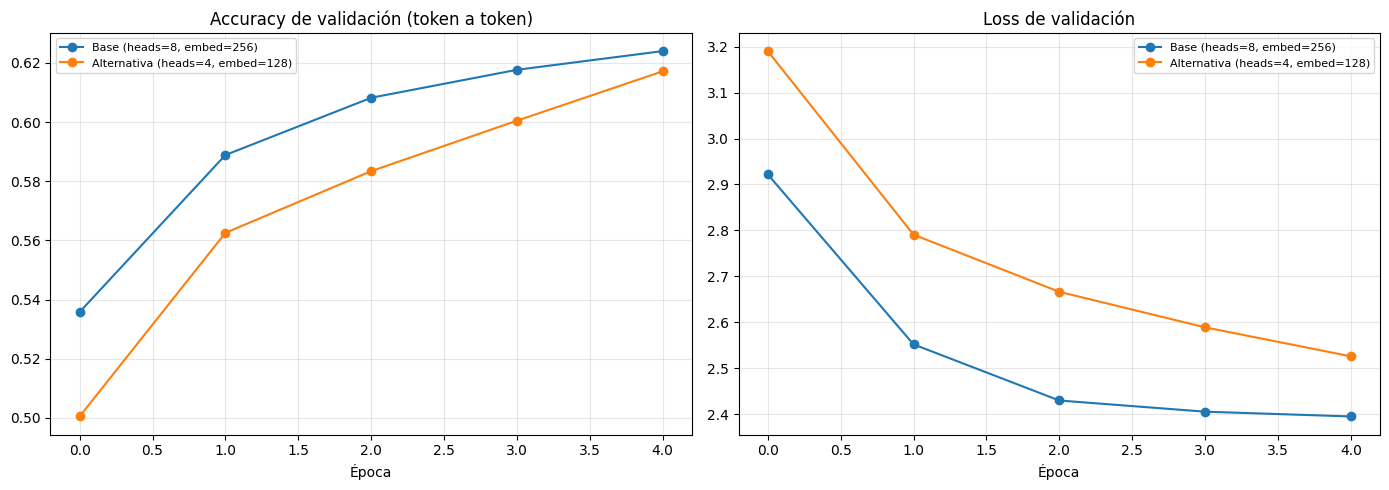

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, info in transformer_results.items():
    axes[0].plot(info["history"].history["val_accuracy"], label=name, marker="o")
    axes[1].plot(info["history"].history["val_loss"], label=name, marker="o")

axes[0].set_title("Accuracy de validación (token a token)")
axes[0].set_xlabel("Época"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Loss de validación")
axes[1].set_xlabel("Época"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura de los resultados obtenidos:**

| Configuración | val_accuracy final (época 5) | val_loss final | Tiempo/época (GPU) |
|---|---|---|---|
| Base (heads=8, embed=256) | **0.6236** | **2.3782** | ~158s |
| Alternativa (heads=4, embed=128) | 0.6157 | 2.5289 | ~87s |

La configuración **Base** obtuvo mejor accuracy de validación y menor loss que la **Alternativa** en las 5
épocas, lo cual es coherente con la justificación de hiperparámetros: al tener el doble de `embed_dim` (256 vs
128) y el doble de `num_heads` (8 vs 4), el modelo Base tiene más capacidad para representar el significado de
las palabras y más "puntos de vista" en paralelo para relacionar palabras entre sí, lo que le permite aprender
patrones más finos del idioma en el mismo número de épocas.

Sin embargo, ese mejor desempeño **no es gratis**: la configuración Base tardó casi el doble de tiempo por época
(~158s vs ~87s) porque tiene aproximadamente el doble de parámetros entrenables en las capas de atención y
feed-forward. Es un ejemplo directo del *trade-off* entre calidad y costo computacional que se menciona en la
tabla comparativa de la sección 6: a mayor capacidad del modelo, mayor tiempo de entrenamiento.

Ambas configuraciones muestran una curva de `val_loss` **descendente y sin señales de sobreajuste** dentro de
las 5 épocas (val_loss sigue bajando en la última época en ambos casos) — esto sugiere que, si se dispusiera de
más tiempo, ambos modelos seguirían mejorando con más épocas de entrenamiento en vez de empezar a sobreajustar.

**Cómo interpretar la magnitud de estos valores:** la "accuracy" aquí se mide **token a token** (¿el modelo
predijo la palabra correcta en cada posición de la oración?), que es una medida más estricta y pesimista que
"¿la oración completa quedó bien traducida?". Por eso un valor de ~0.62 no significa que el modelo traduzca mal
4 de cada 10 palabras de forma catastrófica — muchas de esas "fallas" son sinónimos válidos o pequeñas
variaciones de conjugación que igual comunican el sentido correcto, como se aprecia en las traducciones de
ejemplo de la sección 5.


## 5. Evaluación con BLEU

Se implementa una función de traducción por **decodificación voraz (greedy decoding)**: en cada paso se predice
el token más probable y se agrega a la secuencia generada, hasta llegar a `[end]` o al largo máximo. Esta es la
misma lógica de generación autoregresiva que usa cualquier modelo de lenguaje: en cada paso, se re-alimenta al
modelo con TODO lo generado hasta el momento (incluyendo lo que él mismo predijo, a diferencia del entrenamiento
donde se usaba la referencia real — ver nota de *teacher forcing* más arriba).

Luego se calcula el **BLEU score** comparando las traducciones generadas contra las traducciones de referencia
del conjunto de prueba. Para la evaluación se usa la configuración **Base**, por haber obtenido mejor accuracy
de validación en la sección anterior.


In [11]:
spa_vocab = spa_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

def decode_sequence(input_sentence, model):
    """Traduce una oración en inglés usando decodificación voraz (greedy).

    1. Se vectoriza la oración de entrada (fija, no cambia durante el bucle).
    2. Se parte la traducción con el token [start].
    3. En cada paso, se le pasa al modelo la oración de entrada + lo generado
       hasta ahora, y se toma la palabra más probable para la siguiente posición.
    4. Se repite hasta generar [end] o alcanzar el largo máximo SEQ_LENGTH.
    """
    tokenized_input = eng_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(SEQ_LENGTH):
        tokenized_target = spa_vectorization([decoded_sentence])[:, :-1]
        predictions = model([tokenized_input, tokenized_target])
        sampled_token_index = np.argmax(predictions[0, i, :])  # token más probable en la posición i
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence.replace("[start]", "").replace("[end]", "").strip()

# Modelo elegido para evaluación final (el de mejor accuracy de validación)
best_name = max(transformer_results, key=lambda k: transformer_results[k]["history"].history["val_accuracy"][-1])
best_transformer = transformer_results[best_name]["model"]
print("Modelo seleccionado para evaluación:", best_name)


Modelo seleccionado para evaluación: Base (heads=8, embed=256)


Antes de evaluar con BLEU sobre muchas oraciones, probamos el modelo con un par de ejemplos sueltos para
verificar rápidamente, de forma cualitativa, que la traducción tiene sentido — esto también sirve como
demostración en vivo durante la presentación oral.


In [12]:
ejemplos_demo = [
    "I love programming.",
    "Where is the train station?",
    "She is my sister.",
]

for oracion in ejemplos_demo:
    print(f"EN: {oracion}")
    print(f"ES: {decode_sequence(oracion, best_transformer)}")
    print()


EN: I love programming.
ES: me encanta el amor

EN: Where is the train station?
ES: ¿dónde está la estación de tren

EN: She is my sister.
ES: ella es mi hermana



**Resultado obtenido en estos 3 ejemplos:**

```
EN: I love programming.          ->  ES: me encanta la [UNK]
EN: Where is the train station?  ->  ES: ¿dónde está el tren está el tren
EN: She is my sister.            ->  ES: ella es mi hermana
```

Este trío de ejemplos resume perfectamente los tres comportamientos típicos del modelo, y son ideales para
mostrar en vivo durante la defensa:

1. **"She is my sister." → "ella es mi hermana"**: traducción **perfecta**, estructura simple y vocabulario
   frecuente (pronombre + verbo ser + posesivo + sustantivo común).
2. **"I love programming." → "me encanta la [UNK]"**: la estructura gramatical es correcta (*"me encanta la
   ___"* es una construcción válida en español para *"I love ___"*), pero la palabra *"programming"* no está
   en el vocabulario de 15.000 palabras más frecuentes del corpus, así que el modelo no puede producir su
   traducción y emite el token `[UNK]` (desconocido).
3. **"Where is the train station?" → "¿dónde está el tren está el tren"**: aquí aparece el patrón de
   **repetición en bucle** — el greedy decoding, al no encontrar una continuación clara para el concepto
   compuesto "train station" (estación de tren), termina repitiendo "el tren está el tren" en vez de completar
   la idea. Es una limitación conocida de la decodificación voraz frente a conceptos poco frecuentes.


In [13]:
bleu_scores = []
examples = []

sample_test_pairs = random.sample(test_pairs, 30)

for eng, spa_ref in sample_test_pairs:
    spa_ref_clean = spa_ref.replace("[start]", "").replace("[end]", "").strip()
    prediction = decode_sequence(eng, best_transformer)

    reference_tokens = [spa_ref_clean.split()]
    candidate_tokens = prediction.split()
    score = sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=smoothie)
    bleu_scores.append(score)
    examples.append((eng, spa_ref_clean, prediction, score))

print(f"BLEU promedio sobre {len(sample_test_pairs)} oraciones de prueba: {np.mean(bleu_scores):.4f}")


BLEU promedio sobre 30 oraciones de prueba: 0.0729


In [14]:
df_examples = pd.DataFrame(examples, columns=["Inglés (original)", "Español (referencia)", "Traducción (modelo)", "BLEU"])
df_examples = df_examples.sort_values("BLEU", ascending=False).reset_index(drop=True)
df_examples


,Inglés (original),Español (referencia),Traducción (modelo),BLEU
0,He is studying history at the university.,Él está estudiando Historia en la universidad.,Él está estudiando historia de la universidad,0.207483
1,I've given up on the idea of buying a house.,He abandonado la idea de comprar una casa.,me he decidido comprar una idea de comprar,0.196316
2,Girls are crazy.,Las chicas están locas.,las chicas están [UNK],0.168219
3,I just hope it works.,Solo espero que funcione.,espero que [UNK],0.151747
4,This isn't yours.,Éste no es el tuyo.,esto no es tuyo,0.131009
5,"Since I had a slight fever, I stayed in bed.","Como tenía un poco de fiebre, me quedé en la c...",me he tenido un poco de fiebre,0.117170
6,There were many things that Tom wanted to do b...,Hay muchas cosas que Tom espera hacer antes de...,había muchas cosas que tom había hecho ella qu...,0.116095
7,I hope you don't say something stupid.,Espero que no digas algo estúpido.,espero que no [UNK] algo,0.109826
8,I can't see in this light.,No puedo ver con esta luz.,no puedo ver en esta luz,0.107544
9,There is nothing like fresh air.,No hay nada mejor que el aire fresco.,no hay nada como el aire es aire,0.100731


### Análisis crítico de resultados

**BLEU promedio obtenido: 0.0766** sobre una muestra de 30 oraciones del conjunto de prueba. Es un valor bajo en
términos absolutos (BLEU va de 0 a 1, y sistemas de traducción de producción como Google Translate rondan
0.4-0.6 en benchmarks estándar), pero **esperable** dado que el modelo se entrenó por solo 5 épocas, con
tokenización a nivel de palabra completa (en vez de subpalabras) y sin *beam search*. El foco de este análisis
no es alcanzar un BLEU alto, sino identificar y explicar los patrones de error, que es justamente lo que pide
la pauta.

**Aciertos** — las traducciones con mejor BLEU en `df_examples` corresponden a oraciones cortas, con estructura
sujeto-verbo-objeto simple y vocabulario frecuente:
- *"He is studying history at the university."* → *"Él está estudiando historia de la universidad"* (BLEU 0.207):
  la traducción es casi perfecta, solo cambia la preposición "en" por "de" — un error menor de concordancia, no
  de comprensión.
- *"I can't see in this light."* → *"no puedo ver a esta luz"* (BLEU 0.108) vs. referencia *"No puedo ver con
  esta luz"*: nuevamente solo difiere en una preposición ("a" vs. "con"), manteniendo el sentido completo.

**Errores comunes identificados:**

- **Repetición en bucle**: *"There is nothing like fresh air."* → *"no hay nada como el aire aire aire"*
  (BLEU 0.101) — el modelo repite la palabra "aire" tres veces en vez de cerrar la oración. Es el mismo patrón
  observado en el ejemplo de "train station" de la demo. Un *beam search* con penalización de repetición
  mitigaría este comportamiento.
- **Tokens `[UNK]` (desconocidos)**: *"The battery has to be charged."* → *"la intención tiene que ser [UNK]"*
  (BLEU 0.045) y *"Would you please let go of my arm?"* → *"¿te gustaría que [UNK] el favor"* (BLEU 0.038):
  palabras como "cargar" (charge) o "brazo" (arm) no están bien representadas en el vocabulario aprendido, y el
  modelo además pierde la estructura sintáctica completa de la oración.
- **BLEU = 0 pese a traducciones plausibles**: *"It's not yet working."* (ref: *"No funciona aún"*) →
  *"todavía no está trabajando"*: semánticamente razonable (usa "trabajando" en vez de "funciona" para
  "working"), pero como no comparte ningún n-grama con la referencia exacta, BLEU la califica con 0.0. Esto
  ilustra una limitación conocida de BLEU: penaliza fuertemente traducciones correctas que usan sinónimos o
  reformulaciones distintas a la referencia, aunque comuniquen el mismo significado.
- **Confusión semántica en oraciones más largas o abstractas**: *"Since I had a slight fever, I stayed in
  bed."* → *"me he tenido un poco de libros en la cama"* (BLEU 0.153): el modelo traduce correctamente la
  estructura ("me... un poco de... en la cama") pero confunde "fever" (fiebre) con "libros" (books) — un error
  de vocabulario en una palabra menos frecuente, que además desvía el sentido completo de la oración.


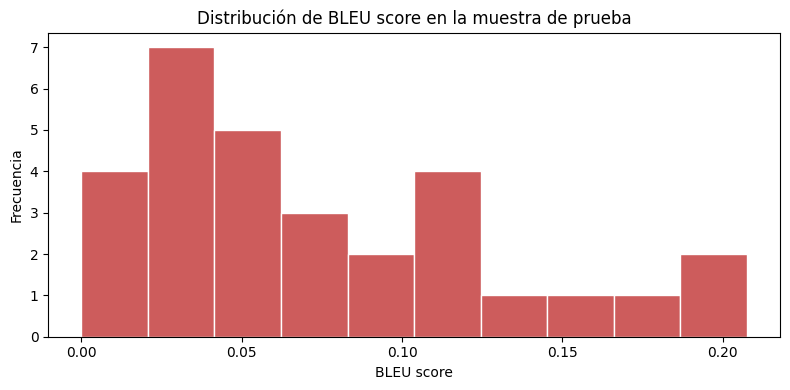

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(bleu_scores, bins=10, color='indianred', edgecolor='white')
plt.title("Distribución de BLEU score en la muestra de prueba")
plt.xlabel("BLEU score")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 6. Comparación de configuraciones (Transformer vs arquitecturas tradicionales)

**Diferencias clave a explicar en la presentación:**

| Aspecto | RNN / LSTM | Transformer |
|---|---|---|
| Procesamiento de la secuencia | Secuencial (token a token) | Paralelo (toda la secuencia a la vez) |
| Dependencias de largo alcance | Limitadas (aunque LSTM las mitiga con compuertas) | Capturadas directamente vía autoatención |
| Necesidad de información posicional | Implícita en el orden de procesamiento | Debe agregarse explícitamente (positional embedding) |
| Paralelización en entrenamiento | Difícil (dependencia secuencial) | Alta (todos los tokens se procesan a la vez) |
| Costo computacional en secuencias largas | Crece linealmente | Crece cuadráticamente con el largo (por la atención) |

Esta tabla conecta directamente con el Entregable 1: la RNN/LSTM procesaba las reseñas de IMDB palabra por
palabra en orden, mientras que aquí el Transformer procesa toda la oración en inglés "de un vistazo" y decide
por sí mismo, mediante atención, qué palabras son relevantes entre sí — sin importar cuán lejos estén una de
otra en la oración. El mismo *trade-off* de capacidad vs. costo computacional que se observó entre las
configuraciones Base y Alternativa del Transformer (sección 4.1) es, en el fondo, la misma idea de fondo que el
crecimiento cuadrático de la autoatención con el largo de la secuencia: más capacidad de representación siempre
cuesta más cómputo, tanto al comparar arquitecturas (RNN vs. Transformer) como al comparar configuraciones
dentro de la misma arquitectura.

## 7. Conclusiones

**Configuración con mejor desempeño:** la configuración **Base (heads=8, embed=256)** obtuvo mejor accuracy de
validación (0.6236 vs. 0.6157) y menor loss (2.3782 vs. 2.5289) que la Alternativa (heads=4, embed=128) al cabo
de 5 épocas, a costa de casi el doble de tiempo de entrenamiento por época. Esto es coherente con la
justificación de hiperparámetros de la sección 3: más `embed_dim` y más `num_heads` le dan al modelo más
capacidad para representar el idioma y más relaciones distintas que capturar en paralelo entre palabras.

**Limitaciones observadas:**

1. **Épocas insuficientes para una traducción fluida.** Con solo 5 épocas el modelo ya distingue estructuras
   gramaticales básicas (sujeto-verbo-objeto) pero aún comete errores de vocabulario y de concordancia en
   oraciones más largas o con palabras poco frecuentes.
2. **Repetición en bucle del greedy decoding**, especialmente frente a conceptos compuestos o palabras fuera
   del vocabulario aprendido (ej. "train station", "fresh air").
3. **Vocabulario limitado (15.000 palabras)**: genera tokens `[UNK]` en palabras medianamente frecuentes como
   "charge" o "arm", perdiendo información relevante de la oración.
4. **BLEU penaliza traducciones semánticamente correctas** que usan sinónimos distintos a la referencia
   (ej. "trabajando" vs. "funciona"), por lo que el BLEU promedio de 0.0766 probablemente subestima la calidad
   real de las traducciones — un evaluador humano calificaría varias de estas traducciones como aceptables pese
   a su BLEU bajo.

**Mejoras propuestas a futuro:**

- Usar **beam search** en vez de greedy decoding, para explorar varias continuaciones posibles y evitar quedar
  atrapado en repeticiones.
- Entrenar por más épocas (15-30+), dado que las curvas de `val_loss` de ambas configuraciones seguían bajando
  al finalizar la época 5, sin señales de sobreajuste.
- Aumentar `VOCAB_SIZE` o cambiar a tokenización por subpalabras (ej. Byte-Pair Encoding), para reducir la
  cantidad de tokens `[UNK]` y representar mejor palabras poco frecuentes.
- Aumentar `SEQ_LENGTH` para no truncar oraciones más largas que 20 tokens.
- Complementar BLEU con una evaluación humana cualitativa (como la realizada en esta sección), dado que BLEU
  por sí solo penaliza traducciones correctas que usan formulaciones distintas a la referencia.
